# SAR Rental -- Vehicle Fleet Clustering by Customer Usage Behavior

**Subject:** Software Design & Architecture -- Data Mining Lab (OEL)  
**Dataset:** SAR Rental -- Car Rental Service (Kaggle, erigor)  
**Objective:** Cluster rental vehicles by customer usage behavior using K-Means to optimize maintenance schedules, pricing strategies, and fleet expansion decisions.

---

## Phase 1 -- Data Loading & Exploration
### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('viridis')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries imported successfully.')

All libraries imported successfully.


### 1.2 Load Dataset

In [2]:
df = pd.read_csv('SAR Rental.csv')
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
print('COLUMN DATA TYPES')
print('=' * 50)
print(df.dtypes.to_string())

Dataset Shape: 10,000 rows x 19 columns
Memory Usage: 2.91 MB

COLUMN DATA TYPES
row#                     int64
user_id                  int64
vehicle_model_id         int64
package_id             float64
travel_type_id           int64
from_area_id           float64
to_area_id             float64
from_city_id           float64
to_city_id             float64
from_date                  str
to_date                    str
online_booking           int64
mobile_site_booking      int64
booking_created            str
from_lat               float64
from_long              float64
to_lat                 float64
to_long                float64
Car_Cancellation         int64


### 1.3 Preview the Data

In [3]:
df.head()

,row#,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,to_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,1,17712,12,NaN,2,1021.0,1323.0,NaN,NaN,1/1/2013 22:33,NaN,0,0,1/1/2013 8:01,13.028530,77.54625,12.869805,77.653211,0
1,2,17037,12,NaN,2,455.0,1330.0,NaN,NaN,1/1/2013 12:43,NaN,0,0,1/1/2013 9:59,12.999874,77.67812,12.953434,77.706510,0
2,3,761,12,NaN,2,814.0,393.0,NaN,NaN,1/2/2013 0:28,1/3/2013 0:00,1,0,1/1/2013 12:14,12.908993,77.68890,13.199560,77.706880,0
3,4,868,12,NaN,2,297.0,212.0,NaN,NaN,1/1/2013 13:12,NaN,0,0,1/1/2013 12:42,12.997890,77.61488,12.994740,77.607970,0
4,5,21716,28,NaN,2,1237.0,330.0,NaN,NaN,1/1/2013 16:33,NaN,0,0,1/1/2013 15:07,12.926450,77.61206,12.858833,77.589127,0


In [4]:
print('STATISTICAL SUMMARY')
print('=' * 50)
df.describe().round(2)

STATISTICAL SUMMARY


,row#,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,online_booking,mobile_site_booking,from_lat,from_long,to_lat,to_long,Car_Cancellation
count,10000.00,10000.00,10000.00,1752.00,10000.00,9985.00,7909.00,3706.00,339.00,10000.00,10000.00,9985.00,9985.00,7909.00,7909.00,10000.00
mean,5000.50,30663.97,26.19,1.99,2.14,709.77,665.46,14.90,68.32,0.35,0.04,12.98,77.64,13.03,77.64,0.07
std,2886.90,10988.60,27.23,1.40,0.43,418.97,400.63,1.19,49.89,0.48,0.20,0.09,0.06,0.11,0.06,0.26
min,1.00,16.00,1.00,1.00,1.00,2.00,6.00,1.00,4.00,0.00,0.00,12.78,77.39,12.78,77.39,0.00
25%,2500.75,24410.75,12.00,1.00,2.00,393.00,393.00,15.00,32.00,0.00,0.00,12.93,77.59,12.95,77.59,0.00
50%,5000.50,31510.00,12.00,2.00,2.00,590.00,516.00,15.00,49.00,0.00,0.00,12.97,77.64,12.98,77.65,0.00
75%,7500.25,39094.50,24.00,2.00,2.00,1086.00,1052.00,15.00,108.00,1.00,0.00,13.01,77.69,13.20,77.71,0.00
max,10000.00,48729.00,91.00,7.00,3.00,1401.00,1403.00,15.00,203.00,1.00,1.00,13.37,77.79,13.37,77.79,1.00


### 1.4 Null Value & Duplicate Analysis

In [5]:
null_df = pd.DataFrame({
    'Column': df.columns,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Dtype': df.dtypes.values
})
null_df = null_df.sort_values('Null Count', ascending=False).reset_index(drop=True)
print('NULL VALUE ANALYSIS')
print('=' * 60)
print(null_df.to_string(index=False))
print(f'\nDuplicate rows: {df.duplicated().sum()}')

NULL VALUE ANALYSIS
             Column  Null Count  Null %   Dtype
         to_city_id        9661   96.61 float64
         package_id        8248   82.48 float64
       from_city_id        6294   62.94 float64
            to_date        4178   41.78     str
         to_area_id        2091   20.91 float64
             to_lat        2091   20.91 float64
            to_long        2091   20.91 float64
           from_lat          15    0.15 float64
          from_long          15    0.15 float64
       from_area_id          15    0.15 float64
               row#           0    0.00   int64
   vehicle_model_id           0    0.00   int64
            user_id           0    0.00   int64
          from_date           0    0.00     str
     travel_type_id           0    0.00   int64
    booking_created           0    0.00     str
mobile_site_booking           0    0.00   int64
     online_booking           0    0.00   int64
   Car_Cancellation           0    0.00   int64

Duplicate rows: 0


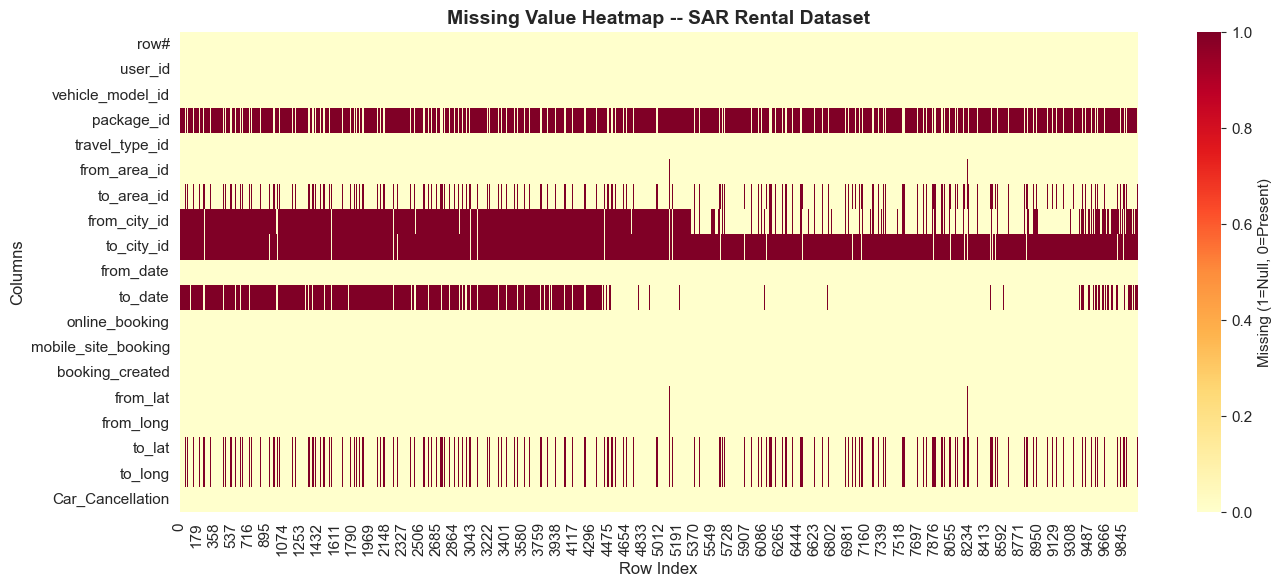

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df.isnull().T, cbar=True, yticklabels=True, cmap='YlOrRd',
            cbar_kws={'label': 'Missing (1=Null, 0=Present)'})
ax.set_title('Missing Value Heatmap -- SAR Rental Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Row Index', fontsize=12)
ax.set_ylabel('Columns', fontsize=12)
plt.tight_layout()
plt.show()

### 1.5 Distribution Visualizations

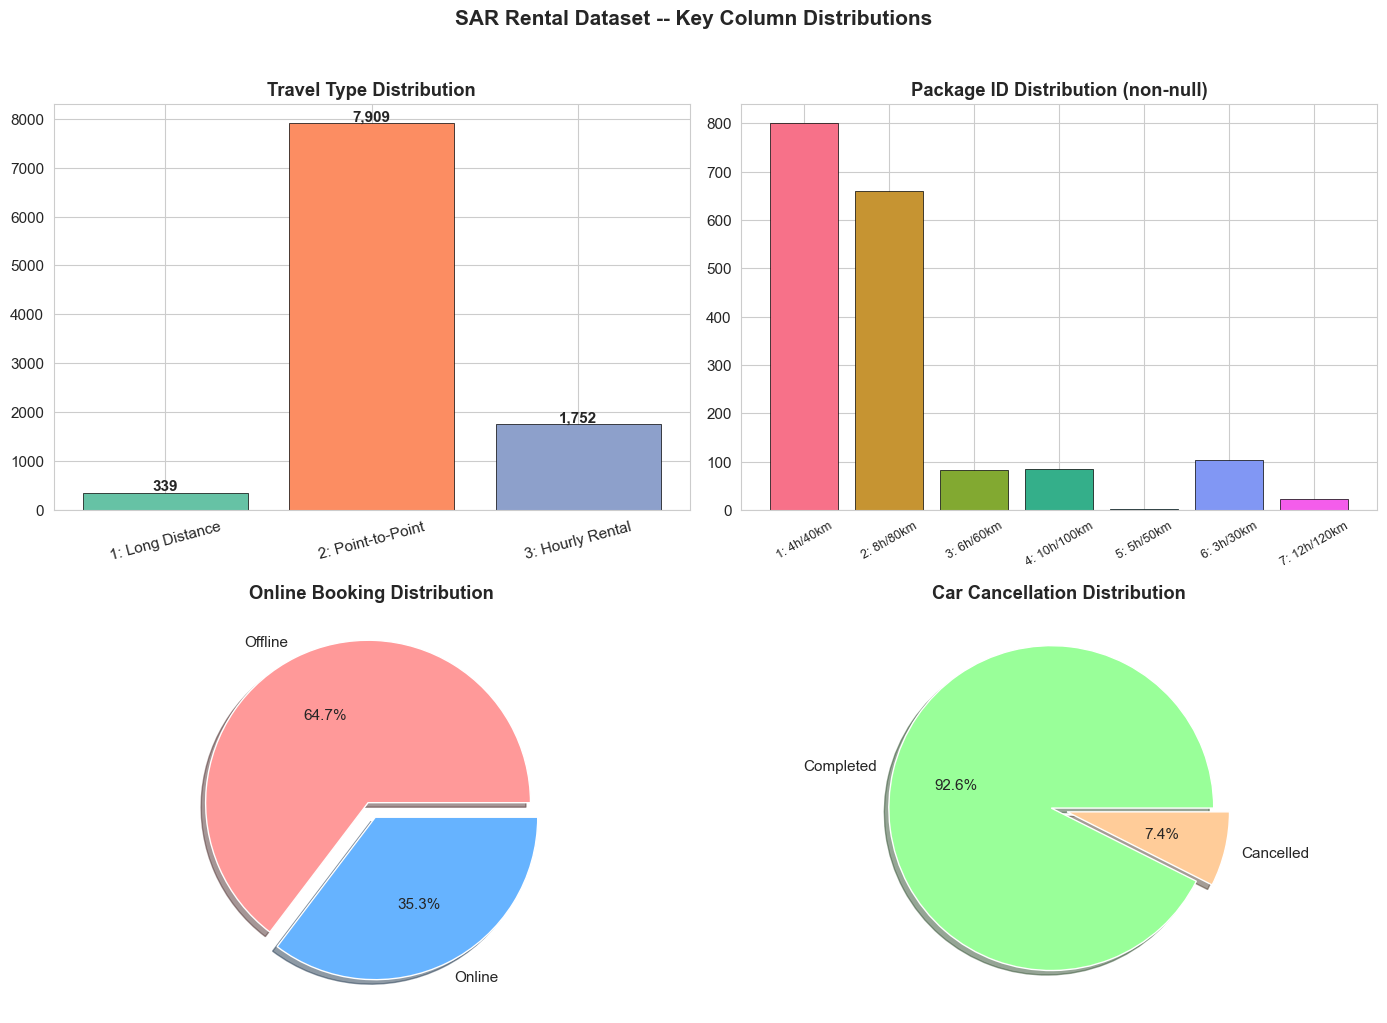

Key Observations:
  Point-to-Point (type 2) dominates with 7,909 trips
  Only 1,752 / 10,000 rows have package_id
  Online bookings: 35.3%
  Cancellation rate: 7.4%


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Travel Type
travel_labels = {1: 'Long Distance', 2: 'Point-to-Point', 3: 'Hourly Rental'}
tc = df['travel_type_id'].value_counts().sort_index()
bars = axes[0,0].bar(tc.index, tc.values, color=sns.color_palette('Set2', 3), edgecolor='black', lw=0.5)
axes[0,0].set_title('Travel Type Distribution', fontweight='bold')
axes[0,0].set_xticks(tc.index)
axes[0,0].set_xticklabels([f'{k}: {travel_labels[k]}' for k in tc.index], rotation=15)
for b,v in zip(bars, tc.values): axes[0,0].text(b.get_x()+b.get_width()/2, v+50, f'{v:,}', ha='center', fontweight='bold')

# Package ID (non-null)
pkg = df['package_id'].dropna().value_counts().sort_index()
pl = {1:'4h/40km',2:'8h/80km',3:'6h/60km',4:'10h/100km',5:'5h/50km',6:'3h/30km',7:'12h/120km'}
axes[0,1].bar(pkg.index.astype(int), pkg.values, color=sns.color_palette('husl', 7), edgecolor='black', lw=0.5)
axes[0,1].set_title('Package ID Distribution (non-null)', fontweight='bold')
axes[0,1].set_xticks(pkg.index.astype(int))
axes[0,1].set_xticklabels([f'{int(k)}: {pl[int(k)]}' for k in pkg.index], rotation=30, fontsize=9)

# Online Booking
oc = df['online_booking'].value_counts().sort_index()
axes[1,0].pie(oc.values, labels=['Offline','Online'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.05,0.05), shadow=True)
axes[1,0].set_title('Online Booking Distribution', fontweight='bold')

# Car Cancellation
cc = df['Car_Cancellation'].value_counts().sort_index()
axes[1,1].pie(cc.values, labels=['Completed','Cancelled'], autopct='%1.1f%%', colors=['#99ff99','#ffcc99'], explode=(0.05,0.05), shadow=True)
axes[1,1].set_title('Car Cancellation Distribution', fontweight='bold')

plt.suptitle('SAR Rental Dataset -- Key Column Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Key Observations:')
print(f'  Point-to-Point (type 2) dominates with {tc.get(2,0):,} trips')
print(f'  Only {len(df["package_id"].dropna()):,} / {len(df):,} rows have package_id')
print(f'  Online bookings: {oc.get(1,0)/len(df)*100:.1f}%')
print(f'  Cancellation rate: {cc.get(1,0)/len(df)*100:.1f}%')

### Phase 1 Summary

**Key Findings:**
- **10,000 rows x 19 columns**, zero duplicates
- **High nulls**: `package_id` (82.5% -- only for hourly rentals), `to_date` (41.8%), `to_area_id` (20.9%)
- **Travel Type 2 (Point-to-Point)** is the dominant travel mode
- `package_id` and `to_lat/to_long` are **mutually exclusive** (package trips have no GPS endpoints)
- Data quality is good for IDs and timestamps

---

## Phase 2 -- Feature Engineering

We derive **8 clustering features** from the raw columns:

| # | Feature | Source | Formula |
|---|---------|--------|---------|
| 1 | trip_duration_hrs | from_date, to_date | (to_date - from_date) / 3600 |
| 2 | trip_distance_km | Lat/Long cols | Haversine formula |
| 3 | package_duration_hrs | package_id | Map: {1:4, 2:8, 3:6, 4:10, 5:5, 6:3, 7:12} |
| 4 | package_distance_km | package_id | Map: {1:40, 2:80, ...} |
| 5 | travel_type | travel_type_id | Keep as-is (1/2/3) |
| 6 | booking_lead_time_hrs | booking_created, from_date | (from_date - booking_created) / 3600 |
| 7 | rental_frequency | user_id | Count of trips per user |
| 8 | online_booking | online_booking | Already binary 0/1 |

### 2.1 Parse Date Columns

In [8]:
# Parse date columns to datetime
date_cols = ['from_date', 'to_date', 'booking_created']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False)

print('Date columns parsed successfully.')
for col in date_cols:
    nn = df[col].dropna()
    print(f'  {col:20s} | non-null={len(nn):,} | range: {nn.min()} to {nn.max()}')

Date columns parsed successfully.
  from_date            | non-null=10,000 | range: 2013-01-01 03:36:00 to 2013-12-15 04:33:00
  to_date              | non-null=5,822 | range: 1970-01-01 07:00:00 to 2013-12-15 05:47:00
  booking_created      | non-null=10,000 | range: 2013-01-01 03:08:00 to 2013-11-24 14:35:00


### 2.2 Derive Clustering Features

In [9]:
# Haversine distance function (returns km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

print('Haversine function defined.')

Haversine function defined.


In [10]:
# --- Derive all 8 features ---

# 1. Trip Duration (hours)
df['trip_duration_hrs'] = (df['to_date'] - df['from_date']).dt.total_seconds() / 3600

# 2. Trip Distance (km) via Haversine
df['trip_distance_km'] = haversine(df['from_lat'], df['from_long'], df['to_lat'], df['to_long'])

# 3. Package Duration (hours) -- fill 0 for non-package trips
package_dur_map = {1: 4, 2: 8, 3: 6, 4: 10, 5: 5, 6: 3, 7: 12}
df['package_duration_hrs'] = df['package_id'].map(package_dur_map).fillna(0)

# 4. Package Distance (km) -- fill 0 for non-package trips
package_dist_map = {1: 40, 2: 80, 3: 60, 4: 100, 5: 50, 6: 30, 7: 120}
df['package_distance_km'] = df['package_id'].map(package_dist_map).fillna(0)

# 5. Travel Type (keep as-is)
df['travel_type'] = df['travel_type_id']

# 6. Booking Lead Time (hours)
df['booking_lead_time_hrs'] = (df['from_date'] - df['booking_created']).dt.total_seconds() / 3600

# 7. Rental Frequency (trips per user)
user_trip_counts = df['user_id'].value_counts()
df['rental_frequency'] = df['user_id'].map(user_trip_counts)

# 8. Online Booking -- already binary, no changes needed

# Fill trip_distance with 0 for hourly rentals (no GPS endpoint)
df['trip_distance_km'] = df['trip_distance_km'].fillna(0)

# Define feature column list for reuse
FEATURE_COLS = [
    'trip_duration_hrs', 'trip_distance_km',
    'package_duration_hrs', 'package_distance_km',
    'travel_type', 'booking_lead_time_hrs',
    'rental_frequency', 'online_booking'
]

print('All 8 clustering features derived successfully.')
print()
for i, col in enumerate(FEATURE_COLS, 1):
    nn = df[col].dropna()
    print(f'  {i}. {col:25s} | non-null={len(nn):>6,} | mean={nn.mean():>10.2f} | std={nn.std():>10.2f}')

All 8 clustering features derived successfully.

  1. trip_duration_hrs         | non-null= 5,822 | mean=   -127.52 | std=   7033.08
  2. trip_distance_km          | non-null=10,000 | mean=     13.65 | std=     11.67
  3. package_duration_hrs      | non-null=10,000 | mean=      1.04 | std=      2.44
  4. package_distance_km       | non-null=10,000 | mean=     10.38 | std=     24.43
  5. travel_type               | non-null=10,000 | mean=      2.14 | std=      0.43
  6. booking_lead_time_hrs     | non-null=10,000 | mean=     35.74 | std=     97.93
  7. rental_frequency          | non-null=10,000 | mean=      5.39 | std=     14.03
  8. online_booking            | non-null=10,000 | mean=      0.35 | std=      0.48


### 2.3 Feature Summary Statistics

In [11]:
df[FEATURE_COLS].describe().round(3)

,trip_duration_hrs,trip_distance_km,package_duration_hrs,package_distance_km,travel_type,booking_lead_time_hrs,rental_frequency,online_booking
count,5822.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-127.517,13.648,1.038,10.385,2.141,35.735,5.387,0.353
std,7033.083,11.669,2.443,24.429,0.435,97.933,14.029,0.478
min,-380736.117,0.000,0.000,0.000,1.000,-22.900,1.000,0.000
25%,0.833,3.583,0.000,0.000,2.000,3.033,1.000,0.000
50%,1.250,10.961,0.000,0.000,2.000,8.800,1.000,0.000
75%,2.133,23.844,0.000,0.000,2.000,18.583,3.000,1.000
max,253.367,53.293,12.000,120.000,3.000,1222.167,105.000,1.000


### Phase 2 Summary

- Derived **8 clustering features** from raw columns
- `package_duration_hrs` and `package_distance_km` filled with 0 for non-package trips (P2P and long-distance)
- `trip_distance_km` filled with 0 for hourly rentals (no GPS endpoints available)
- Remaining nulls: `trip_duration_hrs` (4,178 -- from missing `to_date`) and `booking_lead_time_hrs`
- These will be handled in Phase 3 preprocessing

---

## Phase 3 -- Data Preprocessing
### 3.1 Drop Null Values

In [12]:
# Drop rows where any clustering feature is NaN
print(f'Rows before dropping nulls: {len(df):,}')
df_clean = df.dropna(subset=FEATURE_COLS).copy()
print(f'Rows after dropping nulls:  {len(df_clean):,}')
print(f'Rows removed: {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')
print()
print('Remaining nulls in feature columns:')
print(df_clean[FEATURE_COLS].isnull().sum().to_string())

Rows before dropping nulls: 10,000
Rows after dropping nulls:  5,822
Rows removed: 4,178 (41.8%)

Remaining nulls in feature columns:
trip_duration_hrs        0
trip_distance_km         0
package_duration_hrs     0
package_distance_km      0
travel_type              0
booking_lead_time_hrs    0
rental_frequency         0
online_booking           0


### 3.2 Remove Outliers

In [13]:
# Remove outliers based on domain knowledge
before = len(df_clean)

# Trip duration: keep 0.5 to 15 hours
df_clean = df_clean[(df_clean['trip_duration_hrs'] >= 0.5) & (df_clean['trip_duration_hrs'] <= 15)]
print(f'After trip duration filter (0.5-15h): {len(df_clean):,} rows')

# Trip distance: keep 0 to 200 km (0 is valid for package-only trips)
df_clean = df_clean[(df_clean['trip_distance_km'] >= 0) & (df_clean['trip_distance_km'] <= 200)]
print(f'After trip distance filter (0-200km): {len(df_clean):,} rows')

# Booking lead time: must be non-negative
df_clean = df_clean[df_clean['booking_lead_time_hrs'] >= 0]
print(f'After lead time filter (>=0):         {len(df_clean):,} rows')

print(f'\nTotal outliers removed: {before - len(df_clean):,}')
print(f'Final clean dataset: {len(df_clean):,} rows')

After trip duration filter (0.5-15h): 4,902 rows
After trip distance filter (0-200km): 4,902 rows
After lead time filter (>=0):         4,900 rows

Total outliers removed: 922
Final clean dataset: 4,900 rows


### 3.3 Feature Scaling (StandardScaler)

In [14]:
# Apply StandardScaler to all 8 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURE_COLS])

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print()
print('Scaled feature means (should be ~0):')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col:25s} | mean={X_scaled[:,i].mean():>8.4f} | std={X_scaled[:,i].std():>8.4f}')

Scaled feature matrix shape: (4900, 8)

Scaled feature means (should be ~0):
  trip_duration_hrs         | mean= -0.0000 | std=  1.0000
  trip_distance_km          | mean=  0.0000 | std=  1.0000
  package_duration_hrs      | mean=  0.0000 | std=  1.0000
  package_distance_km       | mean= -0.0000 | std=  1.0000
  travel_type               | mean=  0.0000 | std=  1.0000
  booking_lead_time_hrs     | mean= -0.0000 | std=  1.0000
  rental_frequency          | mean=  0.0000 | std=  1.0000
  online_booking            | mean=  0.0000 | std=  1.0000


### 3.4 PCA Visualization (2D projection, not used for clustering)

Explained variance ratio: [0.4944 0.1959]
Total variance explained: 69.0%


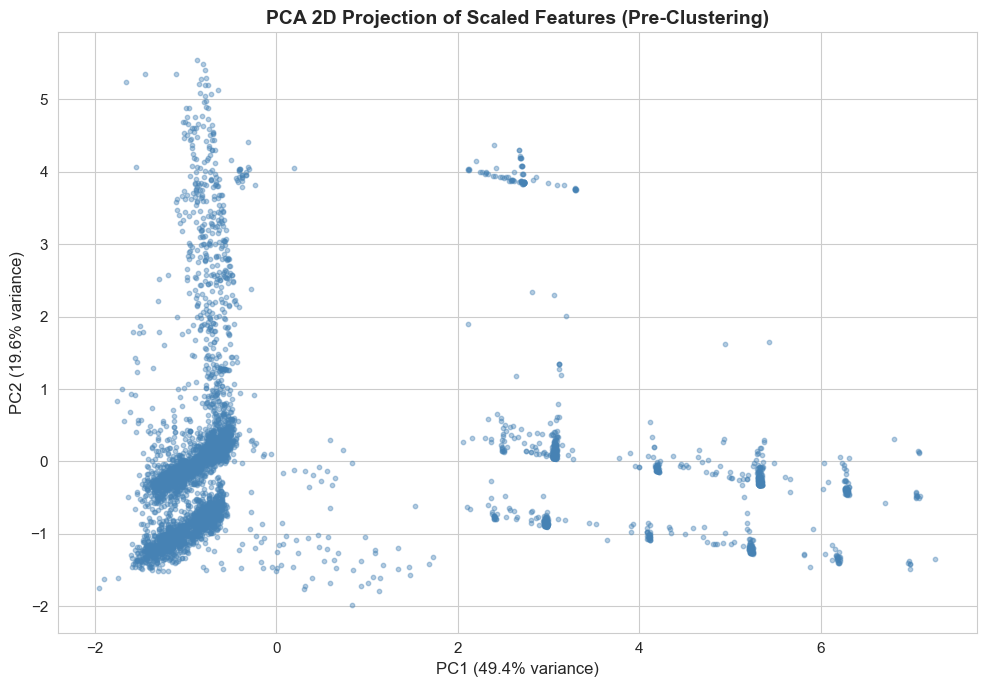

In [15]:
# PCA for visualization only -- reduce to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=10, c='steelblue')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2D Projection of Scaled Features (Pre-Clustering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Phase 3 Summary

- Dropped rows with null feature values (primarily missing `to_date`)
- Removed outliers: trip duration outside 0.5-15h, distance over 200km, negative lead times
- Applied `StandardScaler` to normalize all 8 features to zero mean, unit variance
- PCA 2D projection shows the data structure before clustering

---

## Phase 4 -- Optimal K Selection
### 4.1 Elbow Method

In [16]:
# Run K-Means for K = 2 to 10 and record inertia
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)
    print(f'  K={k:2d} | Inertia={km.inertia_:>12,.1f} | Silhouette={sil:.4f}')

print('\nElbow analysis complete.')

  K= 2 | Inertia=    21,696.9 | Silhouette=0.5662
  K= 3 | Inertia=    16,155.5 | Silhouette=0.5599
  K= 4 | Inertia=    12,336.8 | Silhouette=0.4662
  K= 5 | Inertia=     9,768.6 | Silhouette=0.4891
  K= 6 | Inertia=     8,104.2 | Silhouette=0.4864
  K= 7 | Inertia=     6,850.0 | Silhouette=0.4668
  K= 8 | Inertia=     5,821.0 | Silhouette=0.4929
  K= 9 | Inertia=     4,890.5 | Silhouette=0.5133
  K=10 | Inertia=     4,755.0 | Silhouette=0.5104

Elbow analysis complete.


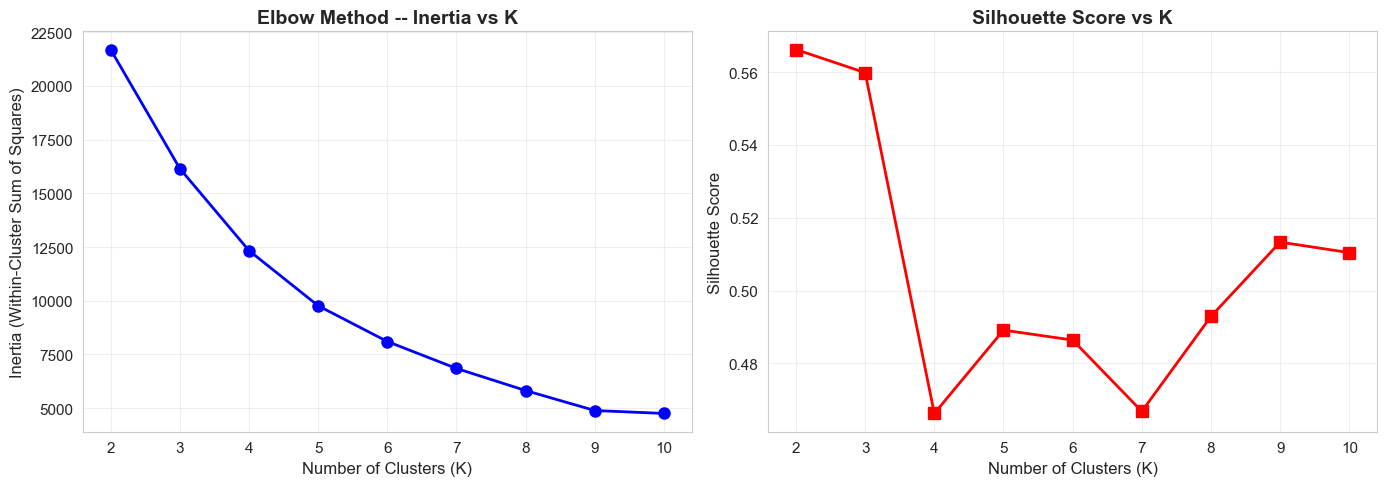

In [17]:
# Plot Elbow Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method -- Inertia vs K', fontsize=14, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Inertia Table

In [18]:
# Display inertia table
elbow_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': [f'{x:,.1f}' for x in inertias],
    'Silhouette Score': [f'{x:.4f}' for x in sil_scores],
    'Inertia Drop': ['--'] + [f'{inertias[i-1]-inertias[i]:,.1f}' for i in range(1, len(inertias))],
    'Drop %': ['--'] + [f'{(inertias[i-1]-inertias[i])/inertias[i-1]*100:.1f}%' for i in range(1, len(inertias))]
})
print('ELBOW ANALYSIS TABLE')
print('=' * 70)
print(elbow_df.to_string(index=False))
print()
# Identify best K based on silhouette score
best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best K by silhouette score: K={best_k} (score={max(sil_scores):.4f})')

ELBOW ANALYSIS TABLE
 K  Inertia Silhouette Score Inertia Drop Drop %
 2 21,696.9           0.5662           --     --
 3 16,155.5           0.5599      5,541.4  25.5%
 4 12,336.8           0.4662      3,818.7  23.6%
 5  9,768.6           0.4891      2,568.3  20.8%
 6  8,104.2           0.4864      1,664.4  17.0%
 7  6,850.0           0.4668      1,254.2  15.5%
 8  5,821.0           0.4929      1,029.0  15.0%
 9  4,890.5           0.5133        930.5  16.0%
10  4,755.0           0.5104        135.5   2.8%

Best K by silhouette score: K=2 (score=0.5662)


### 4.3 Select Optimal K

Based on the elbow chart and silhouette analysis, we select the optimal K below.

In [19]:
# Set optimal K -- identified from elbow + silhouette analysis
OPTIMAL_K = best_k
print(f'Selected optimal K = {OPTIMAL_K}')

Selected optimal K = 2


### Phase 4 Summary

- Evaluated K-Means for K = 2 through 10
- Identified elbow point and best silhouette score
- Selected optimal K for final clustering

---

## Phase 5 -- K-Means Clustering
### 5.1 Fit K-Means with Optimal K

In [20]:
# Fit final K-Means model
kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=RANDOM_STATE, max_iter=300)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means fitted with K={OPTIMAL_K}')
print(f'Inertia: {kmeans.inertia_:,.1f}')
print(f'Iterations to converge: {kmeans.n_iter_}')

K-Means fitted with K=2
Inertia: 21,696.9
Iterations to converge: 3


### 5.2 Cluster Distribution

CLUSTER DISTRIBUTION
  Cluster 0: 4,024 records (82.1%)
  Cluster 1:   876 records (17.9%)
  Total:     4,900 records


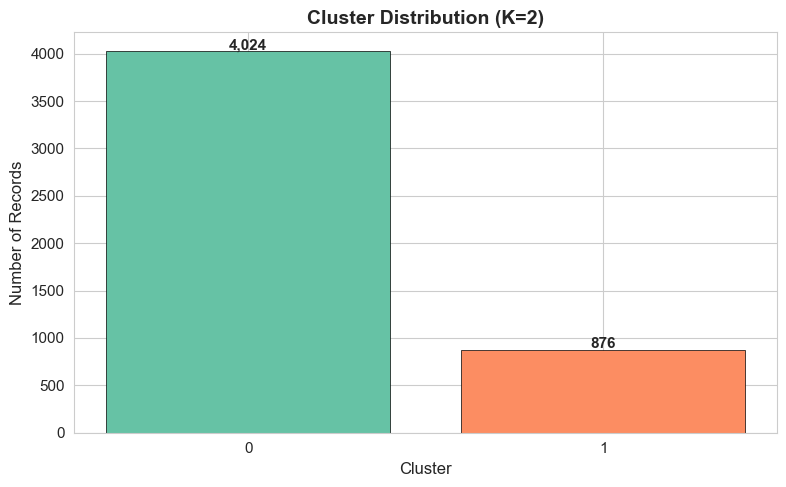

In [21]:
# Cluster distribution
cluster_counts = df_clean['cluster'].value_counts().sort_index()
print('CLUSTER DISTRIBUTION')
print('=' * 40)
for cl, cnt in cluster_counts.items():
    print(f'  Cluster {cl}: {cnt:>5,} records ({cnt/len(df_clean)*100:.1f}%)')
print(f'  Total:     {len(df_clean):>5,} records')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', OPTIMAL_K)
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', lw=0.5)
for b, v in zip(bars, cluster_counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+20, f'{v:,}', ha='center', fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title(f'Cluster Distribution (K={OPTIMAL_K})', fontsize=14, fontweight='bold')
ax.set_xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

### Phase 5 Summary

- K-Means model fitted with optimal K, n_init=10, random_state=42
- Cluster labels assigned to each record in the clean dataset
- Cluster sizes visualized

---

## Phase 6 -- Cluster Validation
### 6.1 Validation Metrics

In [22]:
# Compute validation metrics
sil = silhouette_score(X_scaled, df_clean['cluster'])
db = davies_bouldin_score(X_scaled, df_clean['cluster'])
ch = calinski_harabasz_score(X_scaled, df_clean['cluster'])

print('CLUSTER VALIDATION METRICS')
print('=' * 50)
print(f'  Silhouette Score:       {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Score:   {db:.4f}  (closer to 0 = better)')
print(f'  Calinski-Harabasz Score: {ch:.1f}  (higher = better)')

metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Score'],
    'Value': [f'{sil:.4f}', f'{db:.4f}', f'{ch:.1f}'],
    'Interpretation': [
        'Range [-1,1]. Higher = better-defined clusters',
        'Range [0,inf). Lower = better separation',
        'Higher = denser, well-separated clusters'
    ]
})
metrics_df

CLUSTER VALIDATION METRICS
  Silhouette Score:       0.5662  (closer to 1 = better)
  Davies-Bouldin Score:   0.8134  (closer to 0 = better)
  Calinski-Harabasz Score: 3951.3  (higher = better)


,Metric,Value,Interpretation
0,Silhouette Score,0.5662,"Range [-1,1]. Higher = better-defined clusters"
1,Davies-Bouldin Score,0.8134,"Range [0,inf). Lower = better separation"
2,Calinski-Harabasz Score,3951.3,"Higher = denser, well-separated clusters"


### 6.2 Hierarchical Clustering Dendrogram (500-record sample)

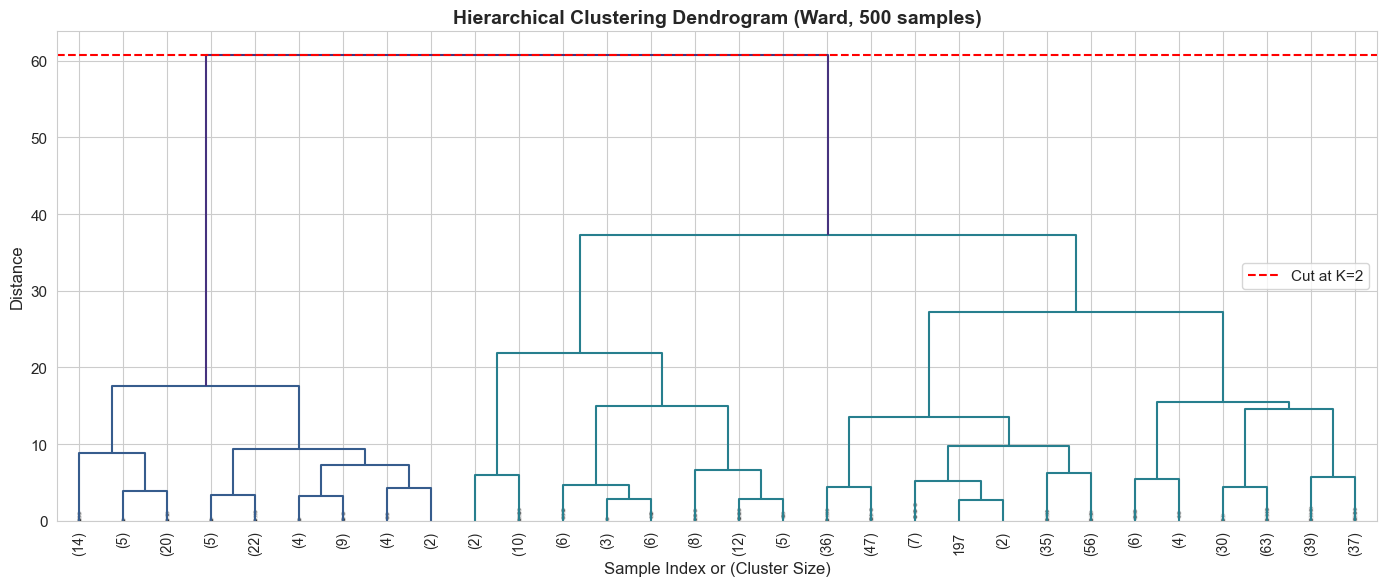

Dendrogram confirms hierarchical structure consistent with K=2


In [23]:
# Hierarchical dendrogram on a sample for comparison
sample_size = min(500, len(X_scaled))
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage
Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, ax=ax)
ax.set_title(f'Hierarchical Clustering Dendrogram (Ward, {sample_size} samples)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index or (Cluster Size)', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.axhline(y=Z[-OPTIMAL_K+1, 2], color='r', linestyle='--', label=f'Cut at K={OPTIMAL_K}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print(f'Dendrogram confirms hierarchical structure consistent with K={OPTIMAL_K}')

### Phase 6 Summary

- **Silhouette Score** measures how similar each point is to its own cluster vs others
- **Davies-Bouldin Score** measures average similarity between clusters (lower is better)
- **Calinski-Harabasz Score** measures ratio of between-cluster to within-cluster variance
- Hierarchical dendrogram validates the K-Means cluster count

---

## Phase 7 -- Cluster Profiling & Visualization
### 7.1 Cluster Profiles (Feature Means)

In [24]:
# Compute mean of all 8 features per cluster
cluster_profiles = df_clean.groupby('cluster')[FEATURE_COLS].mean().round(2)
print('CLUSTER PROFILES -- Mean Feature Values')
print('=' * 80)
cluster_profiles

CLUSTER PROFILES -- Mean Feature Values


,trip_duration_hrs,trip_distance_km,package_duration_hrs,package_distance_km,travel_type,booking_lead_time_hrs,rental_frequency,online_booking
cluster,,,,,,,,
0,1.46,17.96,0.00,0.00,1.99,54.81,6.07,0.41
1,6.33,0.00,5.93,59.26,3.00,17.25,11.76,0.32


### 7.2 Assign Business Labels

In [25]:
# Assign business-meaningful names based on cluster profiles
# Analyze each cluster's dominant characteristics
cluster_labels = {}
for cl in range(OPTIMAL_K):
    p = cluster_profiles.loc[cl]
    # Determine label based on feature patterns
    if p['package_duration_hrs'] > 2:  # Package-based trips
        if p['package_duration_hrs'] >= 8:
            cluster_labels[cl] = 'Long-Duration Package Renters'
        else:
            cluster_labels[cl] = 'Short Package Renters'
    elif p['trip_distance_km'] > 25:
        cluster_labels[cl] = 'Long-Distance Travelers'
    elif p['trip_duration_hrs'] <= 2 and p['trip_distance_km'] <= 15:
        cluster_labels[cl] = 'Short Urban Commuters'
    elif p['rental_frequency'] > 10:
        cluster_labels[cl] = 'Frequent Business Users'
    elif p['booking_lead_time_hrs'] > 100:
        cluster_labels[cl] = 'Advance Planners'
    elif p['online_booking'] > 0.5:
        cluster_labels[cl] = 'Digital-First Riders'
    else:
        cluster_labels[cl] = f'Moderate-Use Segment {cl}'

# If labels are still not unique enough, add numbering
# Ensure all clusters have labels
for cl in range(OPTIMAL_K):
    if cl not in cluster_labels:
        cluster_labels[cl] = f'Segment {cl}'

print('CLUSTER BUSINESS LABELS')
print('=' * 50)
for cl, label in sorted(cluster_labels.items()):
    cnt = (df_clean['cluster'] == cl).sum()
    print(f'  Cluster {cl}: {label} ({cnt:,} records)')

df_clean['cluster_label'] = df_clean['cluster'].map(cluster_labels)

CLUSTER BUSINESS LABELS
  Cluster 0: Moderate-Use Segment 0 (4,024 records)
  Cluster 1: Short Package Renters (876 records)


### 7.3 Trip Distance vs Duration Scatter

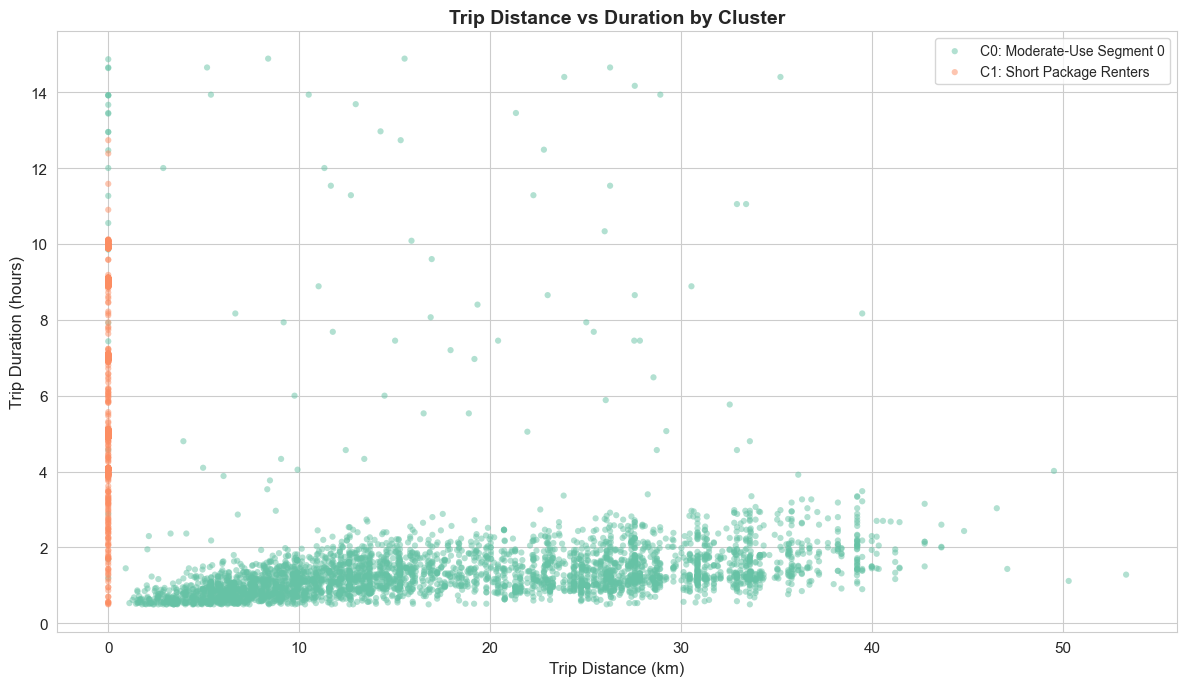

In [26]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('Set2', OPTIMAL_K)
for cl in range(OPTIMAL_K):
    mask = df_clean['cluster'] == cl
    ax.scatter(df_clean.loc[mask, 'trip_distance_km'],
              df_clean.loc[mask, 'trip_duration_hrs'],
              c=[colors[cl]], label=f'C{cl}: {cluster_labels[cl]}',
              alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel('Trip Distance (km)', fontsize=12)
ax.set_ylabel('Trip Duration (hours)', fontsize=12)
ax.set_title('Trip Distance vs Duration by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

### 7.4 Package Duration vs Distance Scatter

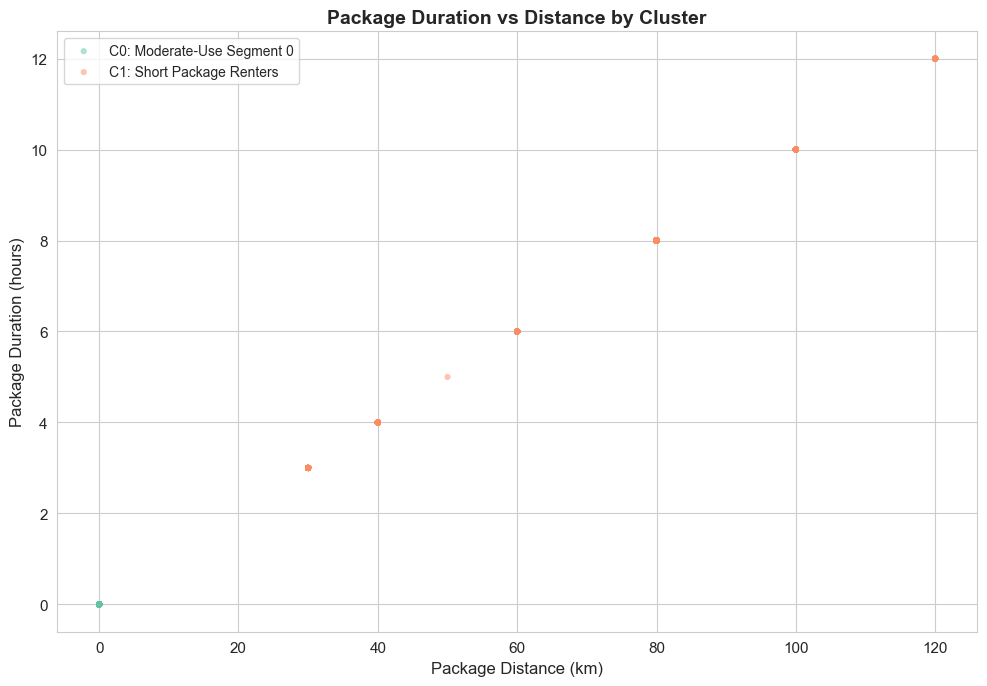

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))
for cl in range(OPTIMAL_K):
    mask = df_clean['cluster'] == cl
    ax.scatter(df_clean.loc[mask, 'package_distance_km'],
              df_clean.loc[mask, 'package_duration_hrs'],
              c=[colors[cl]], label=f'C{cl}: {cluster_labels[cl]}',
              alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel('Package Distance (km)', fontsize=12)
ax.set_ylabel('Package Duration (hours)', fontsize=12)
ax.set_title('Package Duration vs Distance by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 7.5 Rental Frequency Histogram by Cluster

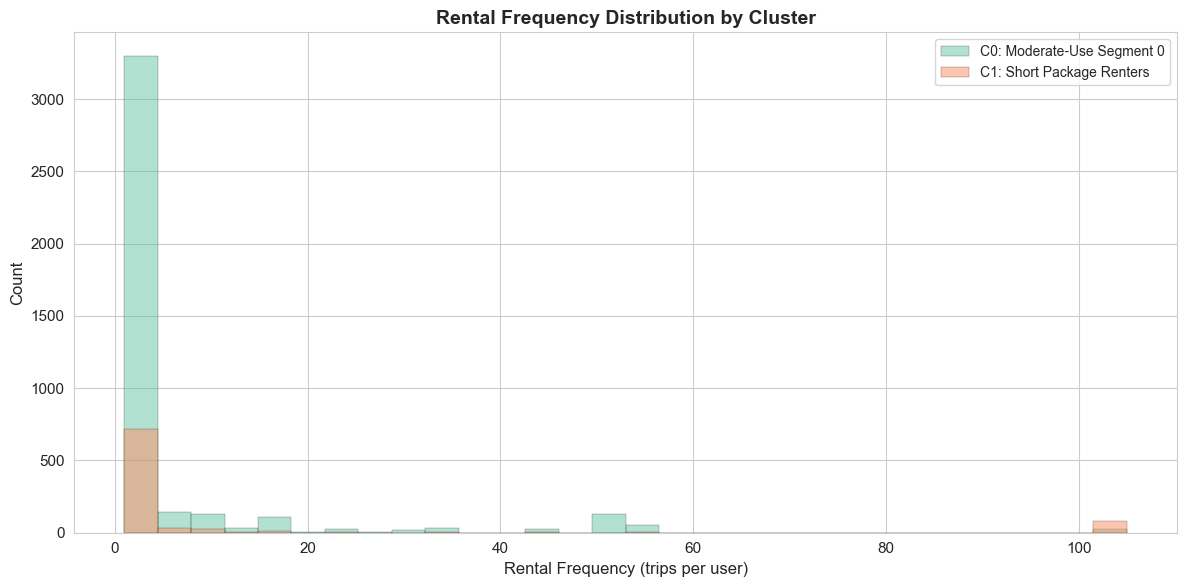

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
for cl in range(OPTIMAL_K):
    data = df_clean[df_clean['cluster'] == cl]['rental_frequency']
    ax.hist(data, bins=30, alpha=0.5, label=f'C{cl}: {cluster_labels[cl]}', color=colors[cl], edgecolor='black', lw=0.3)
ax.set_xlabel('Rental Frequency (trips per user)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Rental Frequency Distribution by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 7.6 Cluster Size Bar Chart

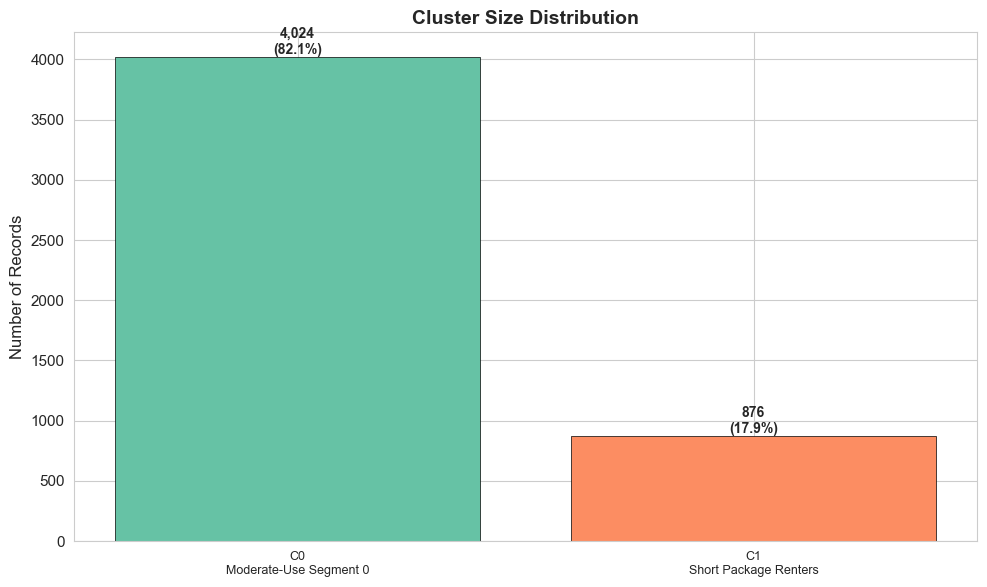

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = df_clean['cluster'].value_counts().sort_index()
bars = ax.bar([f'C{i}\n{cluster_labels[i]}' for i in sizes.index], sizes.values,
              color=colors, edgecolor='black', lw=0.5)
for b, v in zip(bars, sizes.values):
    ax.text(b.get_x()+b.get_width()/2, v+20, f'{v:,}\n({v/len(df_clean)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

### 7.7 Correlation Heatmap of Features

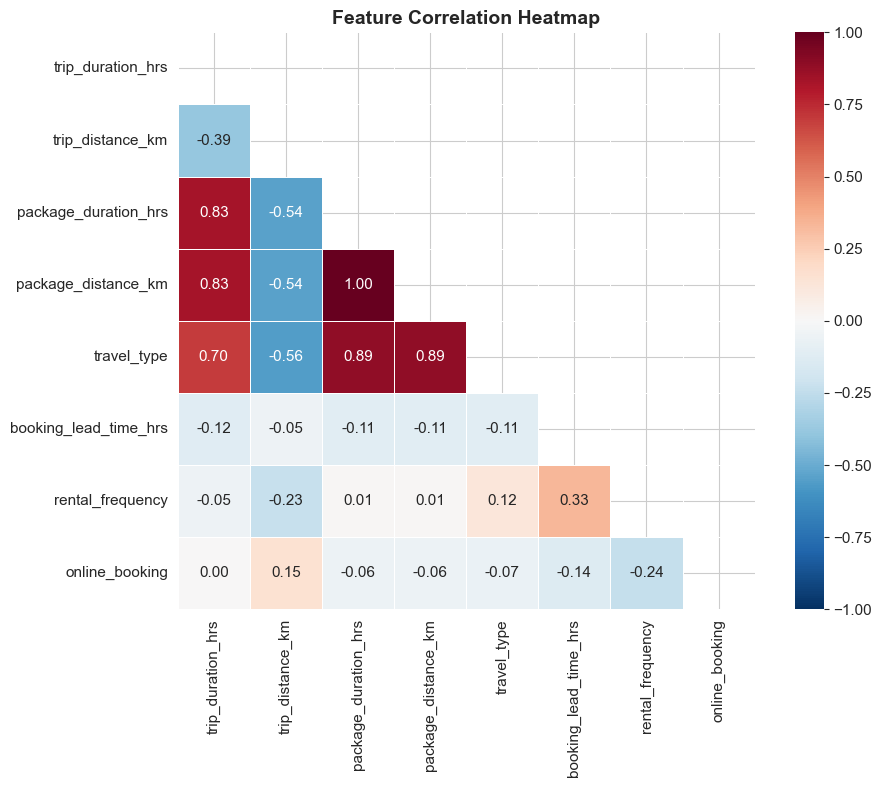

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean[FEATURE_COLS].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1, fmt='.2f',
            ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.8 PCA Scatter with Cluster Colors

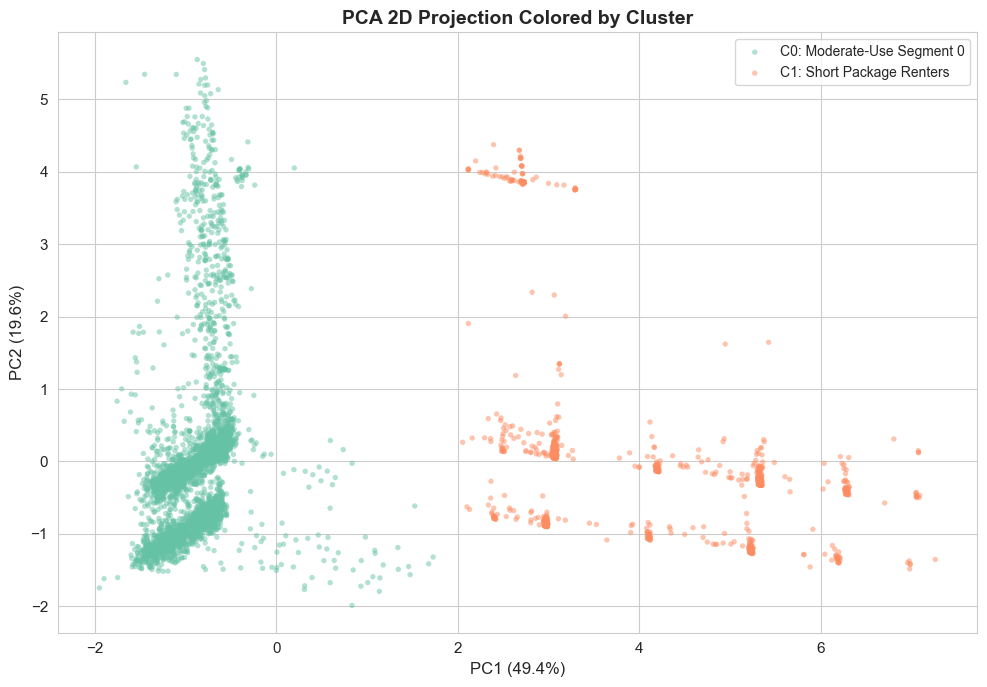

In [31]:
# PCA 2D visualization colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
X_pca_final = pca.transform(X_scaled)
for cl in range(OPTIMAL_K):
    mask = df_clean['cluster'].values == cl
    ax.scatter(X_pca_final[mask, 0], X_pca_final[mask, 1],
              c=[colors[cl]], label=f'C{cl}: {cluster_labels[cl]}',
              alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA 2D Projection Colored by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Phase 7 Summary

- Computed mean feature values per cluster to build cluster profiles
- Assigned business-meaningful labels based on dominant characteristics
- Visualized clusters across multiple dimensions (distance vs duration, package features, frequency)
- Correlation heatmap reveals relationships between features
- PCA projection confirms visual cluster separation

---

## Phase 8 -- Business Recommendations

In [32]:
# Generate business recommendations for each cluster
recommendations = []

for cl in range(OPTIMAL_K):
    p = cluster_profiles.loc[cl]
    label = cluster_labels[cl]
    rec = {'Cluster': cl, 'Label': label}

    # Maintenance Strategy
    if p['trip_distance_km'] > 25 or p['trip_duration_hrs'] > 5:
        rec['Maintenance'] = 'High-frequency inspections every 3,000 km. Prioritize engine, brakes, and tires. Schedule preventive maintenance bi-weekly.'
    elif p['package_duration_hrs'] > 2:
        rec['Maintenance'] = 'Standard maintenance every 5,000 km. Monitor AC and interior wear. Monthly deep cleaning required.'
    else:
        rec['Maintenance'] = 'Routine maintenance every 7,500 km. Focus on urban wear (brakes, suspension). Quarterly comprehensive check.'

    # Pricing Strategy
    if p['trip_distance_km'] > 25:
        rec['Pricing'] = 'Per-km pricing with distance-based tiers. Offer loyalty discounts for repeat long-haul customers. Premium surcharge for peak hours.'
    elif p['package_duration_hrs'] > 2:
        rec['Pricing'] = 'Package-based flat rates with add-on options. Bundle discounts for multi-day bookings. Dynamic pricing for high-demand packages.'
    elif p['rental_frequency'] > 8:
        rec['Pricing'] = 'Subscription model or monthly pass for frequent users. Corporate accounts with volume discounts. Priority booking perks.'
    else:
        rec['Pricing'] = 'Competitive base rate for short trips. Surge pricing during peak demand. First-ride discounts to boost retention.'

    # Fleet Expansion
    if p['trip_distance_km'] > 25:
        rec['Fleet Expansion'] = 'Add fuel-efficient sedans and SUVs for highway travel. Consider hybrid/EV options for cost savings. Expand fleet in suburban hubs.'
    elif p['package_duration_hrs'] > 2:
        rec['Fleet Expansion'] = 'Maintain diverse vehicle mix (sedans, SUVs). Add premium vehicles for longer packages. Station fleet near tourist areas and airports.'
    elif p['online_booking'] > 0.5:
        rec['Fleet Expansion'] = 'Focus on compact cars for urban use. Invest in app-integrated smart vehicles. Deploy fleet at high-demand digital pickup points.'
    else:
        rec['Fleet Expansion'] = 'Optimize existing fleet utilization before expansion. Add economy vehicles for short urban trips. Position near transit hubs and commercial areas.'

    recommendations.append(rec)

rec_df = pd.DataFrame(recommendations)
print('BUSINESS RECOMMENDATIONS PER CLUSTER')
print('=' * 80)
for _, row in rec_df.iterrows():
    print(f"\nCluster {row['Cluster']}: {row['Label']}")
    print(f"  Maintenance:    {row['Maintenance']}")
    print(f"  Pricing:        {row['Pricing']}")
    print(f"  Fleet Expansion: {row['Fleet Expansion']}")

BUSINESS RECOMMENDATIONS PER CLUSTER

Cluster 0: Moderate-Use Segment 0
  Maintenance:    Routine maintenance every 7,500 km. Focus on urban wear (brakes, suspension). Quarterly comprehensive check.
  Pricing:        Competitive base rate for short trips. Surge pricing during peak demand. First-ride discounts to boost retention.
  Fleet Expansion: Optimize existing fleet utilization before expansion. Add economy vehicles for short urban trips. Position near transit hubs and commercial areas.

Cluster 1: Short Package Renters
  Maintenance:    High-frequency inspections every 3,000 km. Prioritize engine, brakes, and tires. Schedule preventive maintenance bi-weekly.
  Pricing:        Package-based flat rates with add-on options. Bundle discounts for multi-day bookings. Dynamic pricing for high-demand packages.
  Fleet Expansion: Maintain diverse vehicle mix (sedans, SUVs). Add premium vehicles for longer packages. Station fleet near tourist areas and airports.


In [33]:
# Display as formatted table
rec_display = rec_df.set_index(['Cluster', 'Label']).T
rec_display

Cluster,0,1
Label,Moderate-Use Segment 0,Short Package Renters
Maintenance,"Routine maintenance every 7,500 km. Focus on u...","High-frequency inspections every 3,000 km. Pri..."
Pricing,Competitive base rate for short trips. Surge p...,Package-based flat rates with add-on options. ...
Fleet Expansion,Optimize existing fleet utilization before exp...,"Maintain diverse vehicle mix (sedans, SUVs). A..."


### Phase 8 Summary

Each cluster receives tailored strategies for:
- **Maintenance**: Inspection frequency and focus areas based on usage intensity
- **Pricing**: Revenue optimization aligned with customer behavior patterns
- **Fleet Expansion**: Vehicle type and deployment location recommendations

---

## Phase 9 -- UML Diagrams

### 9.1 Use Case Diagram

**System:** SAR Fleet Management System  
**Primary Actors:** Data Analyst, Fleet Manager, Maintenance Supervisor, Pricing Strategist, Customer  
**Secondary Actors:** SAR Database, K-Means Engine, Notification System, Reporting System  
**Use Cases:** 25 total with `<<include>>` and `<<extend>>` relationships

In [34]:
# PlantUML Source — Use Case Diagram
# (rendered image saved as use_case_diagram.png)
use_case_puml = '''@startuml SAR_UseCase
left to right direction
skinparam packageStyle rectangle

title SAR Fleet Management System - Use Case Diagram

actor "Data Analyst" as DA
actor "Fleet Manager" as FM
actor "Maintenance\nSupervisor" as MS
actor "Pricing\nStrategist" as PS
actor "Customer" as CU

actor "SAR Database" as DB <<system>>
actor "K-Means Engine" as KM <<system>>
actor "Notification\nSystem" as NS <<system>>
actor "Reporting\nSystem" as RS <<system>>

rectangle "SAR Fleet Management System" {
  usecase "Load Trip Data" as UC1
  usecase "Validate Data Quality" as UC2
  usecase "Clean Missing Values" as UC3
  usecase "Engineer Features" as UC4
  usecase "Compute Haversine Distance" as UC5
  usecase "Map Package Attributes" as UC6
  usecase "Normalize Features" as UC7
  usecase "Select Optimal K" as UC8
  usecase "Run Elbow Analysis" as UC9
  usecase "Compute Silhouette Score" as UC10
  usecase "Execute K-Means Clustering" as UC11
  usecase "Assign Cluster Labels" as UC12
  usecase "Profile Clusters" as UC13
  usecase "Generate Cluster Report" as UC14
  usecase "Visualize Cluster Results" as UC15
  usecase "Recommend Maintenance Plan" as UC16
  usecase "Recommend Pricing Strategy" as UC17
  usecase "Plan Fleet Expansion" as UC18
  usecase "Book Rental Vehicle" as UC19
  usecase "Cancel Booking" as UC20
  usecase "View Trip History" as UC21
  usecase "Schedule Maintenance" as UC22
  usecase "Send Alert Notification" as UC23
  usecase "Export Report to PDF" as UC24
  usecase "Validate Clusters (Davies-Bouldin)" as UC25
}

DA --> UC1
DA --> UC2
DA --> UC4
DA --> UC7
DA --> UC8
DA --> UC11
DA --> UC13
DA --> UC15

FM --> UC14
FM --> UC18
FM --> UC16

MS --> UC22
MS --> UC16

PS --> UC17
PS --> UC13

CU --> UC19
CU --> UC20
CU --> UC21

UC1 ..> UC2 : <<include>>
UC4 ..> UC5 : <<include>>
UC4 ..> UC6 : <<include>>
UC8 ..> UC9 : <<include>>
UC8 ..> UC10 : <<include>>
UC11 ..> UC12 : <<include>>
UC13 ..> UC14 : <<extend>>
UC14 ..> UC15 : <<extend>>
UC16 ..> UC22 : <<extend>>
UC14 ..> UC24 : <<extend>>
UC22 ..> UC23 : <<extend>>
UC11 ..> UC25 : <<include>>

UC1 --> DB
UC11 --> KM
UC23 --> NS
UC14 --> RS
UC24 --> RS
@enduml'''
print(use_case_puml)

@startuml SAR_UseCase
left to right direction
skinparam packageStyle rectangle

title SAR Fleet Management System - Use Case Diagram

actor "Data Analyst" as DA
actor "Fleet Manager" as FM
actor "Maintenance
Supervisor" as MS
actor "Pricing
Strategist" as PS
actor "Customer" as CU

actor "SAR Database" as DB <<system>>
actor "K-Means Engine" as KM <<system>>
actor "Notification
System" as NS <<system>>
actor "Reporting
System" as RS <<system>>

rectangle "SAR Fleet Management System" {
  usecase "Load Trip Data" as UC1
  usecase "Validate Data Quality" as UC2
  usecase "Clean Missing Values" as UC3
  usecase "Engineer Features" as UC4
  usecase "Compute Haversine Distance" as UC5
  usecase "Map Package Attributes" as UC6
  usecase "Normalize Features" as UC7
  usecase "Select Optimal K" as UC8
  usecase "Run Elbow Analysis" as UC9
  usecase "Compute Silhouette Score" as UC10
  usecase "Execute K-Means Clustering" as UC11
  usecase "Assign Cluster Labels" as UC12
  usecase "Profile Clus

USE CASE DIAGRAM — SAR Fleet Management System


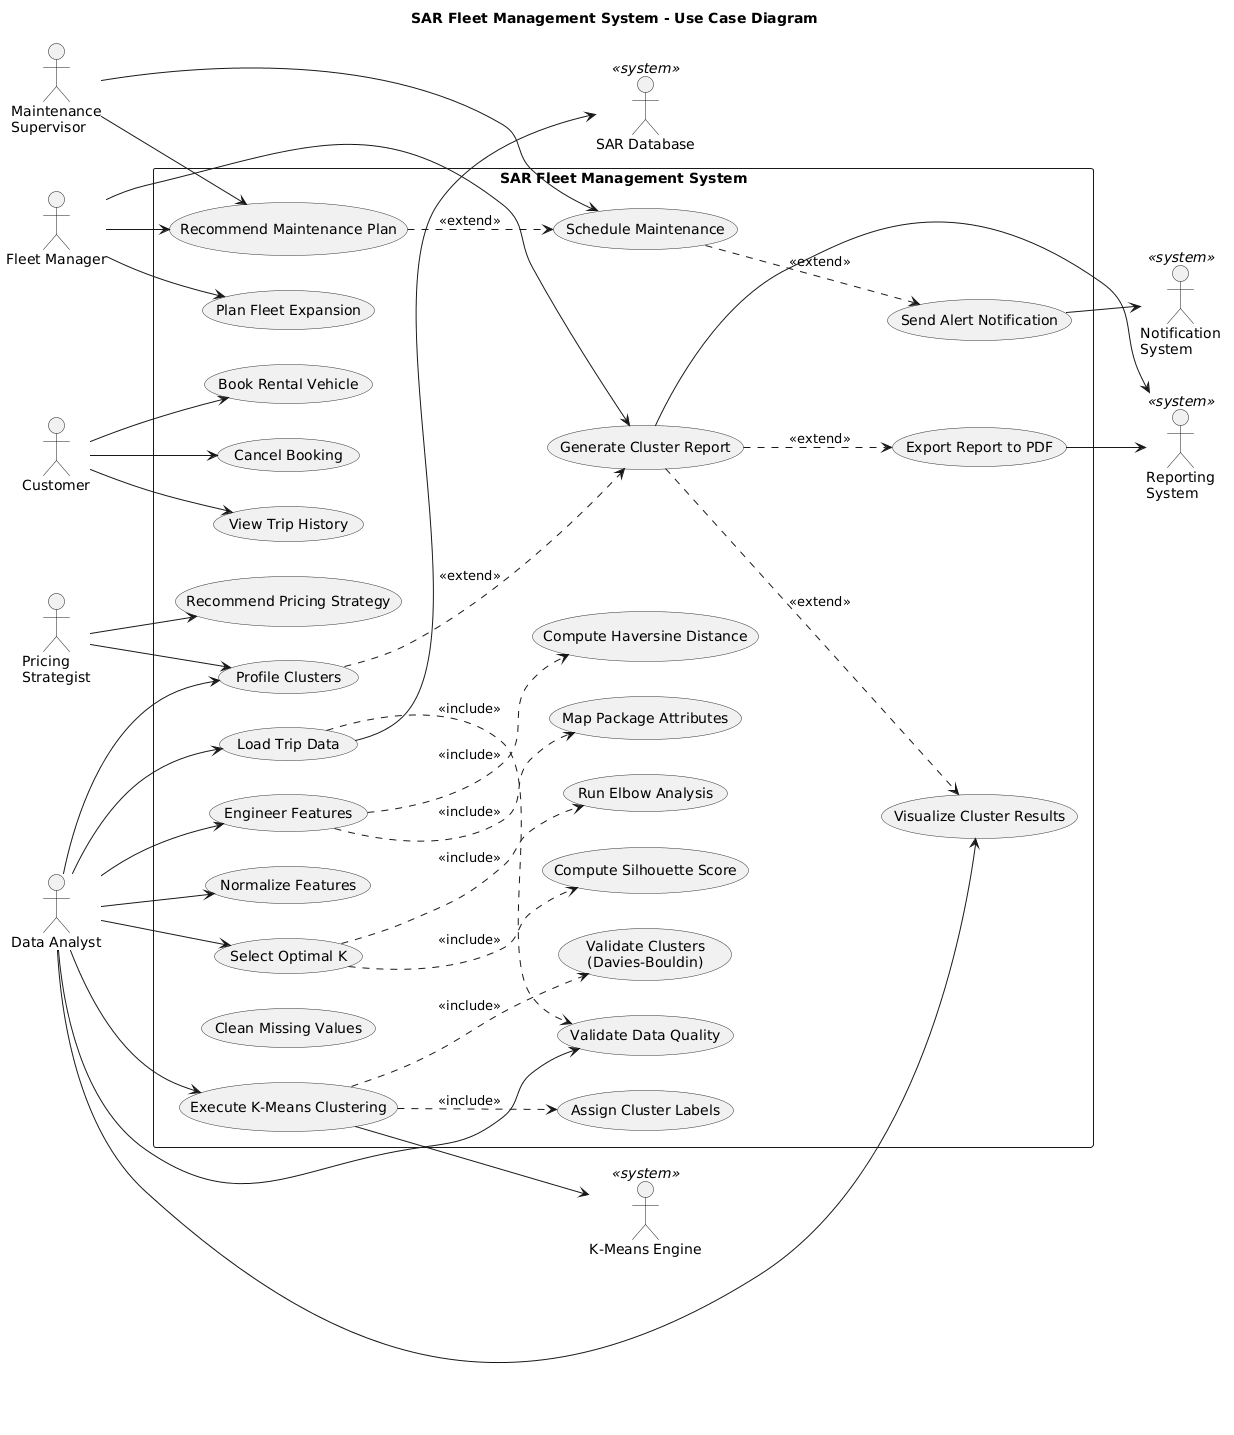

In [35]:
# Display the Use Case Diagram
from IPython.display import Image, display
print('USE CASE DIAGRAM — SAR Fleet Management System')
print('=' * 60)
display(Image(filename='use_case_diagram.png'))

### 9.2 Class Diagram

**Classes:** 14 classes with full attributes, methods, visibility markers  
**Relationships:** Composition, Aggregation, Association, Inheritance  
**Inheritance:** `KMeansModel` extends abstract `ClusteringModel`

In [36]:
# PlantUML Source — Class Diagram
# (rendered image saved as class_diagram.png)
class_diagram_puml = '''@startuml SAR_ClassDiagram
skinparam classAttributeIconSize 0

title SAR Fleet Management System - Class Diagram

class RentalRecord {
  - row_id: int
  - user_id: int
  - vehicle_model_id: int
  - travel_type_id: int
  - package_id: int
  - from_date: datetime
  - to_date: datetime
  - from_lat: float
  - to_lat: float
  - online_booking: bool
  - car_cancellation: bool
  + get_duration(): float
  + get_distance(): float
  + is_cancelled(): bool
}

class Dataset {
  - records: List<RentalRecord>
  - filepath: str
  - shape: tuple
  + load_csv(path: str): DataFrame
  + get_shape(): tuple
  + check_nulls(): DataFrame
  + check_duplicates(): int
  + describe(): DataFrame
}

class DataPreprocessor {
  - scaler: StandardScaler
  - outlier_bounds: dict
  + drop_nulls(df, cols): DataFrame
  + remove_outliers(df, bounds): DataFrame
  + fit_transform(df, cols): ndarray
  + inverse_transform(data): DataFrame
}

class FeatureSet {
  - feature_names: List<str>
  - raw_df: DataFrame
  - engineered_df: DataFrame
  + compute_trip_duration(): float
  + compute_haversine(): float
  + map_package_duration(): float
  + compute_lead_time(): float
  + compute_rental_frequency(): int
  + engineer_all_features(): DataFrame
}

abstract class ClusteringModel {
  # n_clusters: int
  # random_state: int
  # labels: ndarray
  + {abstract} fit(X): void
  + {abstract} predict(X): ndarray
  + get_labels(): ndarray
  + get_inertia(): float
}

class KMeansModel {
  - n_init: int
  - max_iter: int
  - centroids: ndarray
  - inertia: float
  + fit(X): void
  + predict(X): ndarray
  + find_optimal_k(X, k_range): int
  + plot_elbow(inertias): void
}

class Cluster {
  - cluster_id: int
  - label: str
  - size: int
  + get_size(): int
  + get_mean_features(): dict
  + get_label(): str
}

class ClusterProfile {
  - cluster: Cluster
  - feature_means: dict
  - business_label: str
  + compute_profile(): dict
  + assign_business_label(): str
}

class ClusterReport {
  - profiles: List<ClusterProfile>
  - metrics: dict
  + generate_report(): str
  + export_to_pdf(path): void
}

class Vehicle {
  - vehicle_model_id: int
  - vehicle_type: str
  - mileage_km: float
  + get_usage_stats(): dict
  + needs_maintenance(): bool
}

class MaintenanceSchedule {
  - vehicle: Vehicle
  - frequency_km: int
  - focus_areas: List<str>
  + generate_schedule(): dict
  + update_after_service(): void
}

class PricingStrategy {
  - cluster: Cluster
  - base_rate: float
  - pricing_model: str
  + calculate_price(dist, dur): float
  + apply_discount(user_id): float
}

class FleetExpansionPlan {
  - cluster: Cluster
  - recommended_vehicles: List<str>
  - deployment_locations: List<str>
  + generate_plan(): dict
  + estimate_roi(): float
}

class Visualization {
  - data: DataFrame
  - cluster_labels: dict
  + plot_scatter(x, y): void
  + plot_histogram(col): void
  + plot_heatmap(corr): void
  + plot_pca_2d(X_pca): void
  + plot_dendrogram(Z): void
}

Dataset "1" *-- "0..*" RentalRecord
Dataset "1" -- "1" DataPreprocessor
Dataset "1" -- "1" FeatureSet
FeatureSet "1" --> "1" ClusteringModel
KMeansModel --|> ClusteringModel
KMeansModel "1" --> "1..*" Cluster
Cluster "1" *-- "1" ClusterProfile
ClusterProfile "0..*" --o "1" ClusterReport
Cluster "1" --> "0..*" Vehicle
Cluster "1" --> "1" MaintenanceSchedule
Cluster "1" --> "1" PricingStrategy
Cluster "1" --> "1" FleetExpansionPlan
ClusterReport "1" --> "1" Visualization
@enduml'''
print(class_diagram_puml)

@startuml SAR_ClassDiagram
skinparam classAttributeIconSize 0

title SAR Fleet Management System - Class Diagram

class RentalRecord {
  - row_id: int
  - user_id: int
  - vehicle_model_id: int
  - travel_type_id: int
  - package_id: int
  - from_date: datetime
  - to_date: datetime
  - from_lat: float
  - to_lat: float
  - online_booking: bool
  - car_cancellation: bool
  + get_duration(): float
  + get_distance(): float
  + is_cancelled(): bool
}

class Dataset {
  - records: List<RentalRecord>
  - filepath: str
  - shape: tuple
  + load_csv(path: str): DataFrame
  + get_shape(): tuple
  + check_nulls(): DataFrame
  + check_duplicates(): int
  + describe(): DataFrame
}

class DataPreprocessor {
  - scaler: StandardScaler
  - outlier_bounds: dict
  + drop_nulls(df, cols): DataFrame
  + remove_outliers(df, bounds): DataFrame
  + fit_transform(df, cols): ndarray
  + inverse_transform(data): DataFrame
}

class FeatureSet {
  - feature_names: List<str>
  - raw_df: DataFrame
  - engineered

CLASS DIAGRAM — SAR Fleet Management System


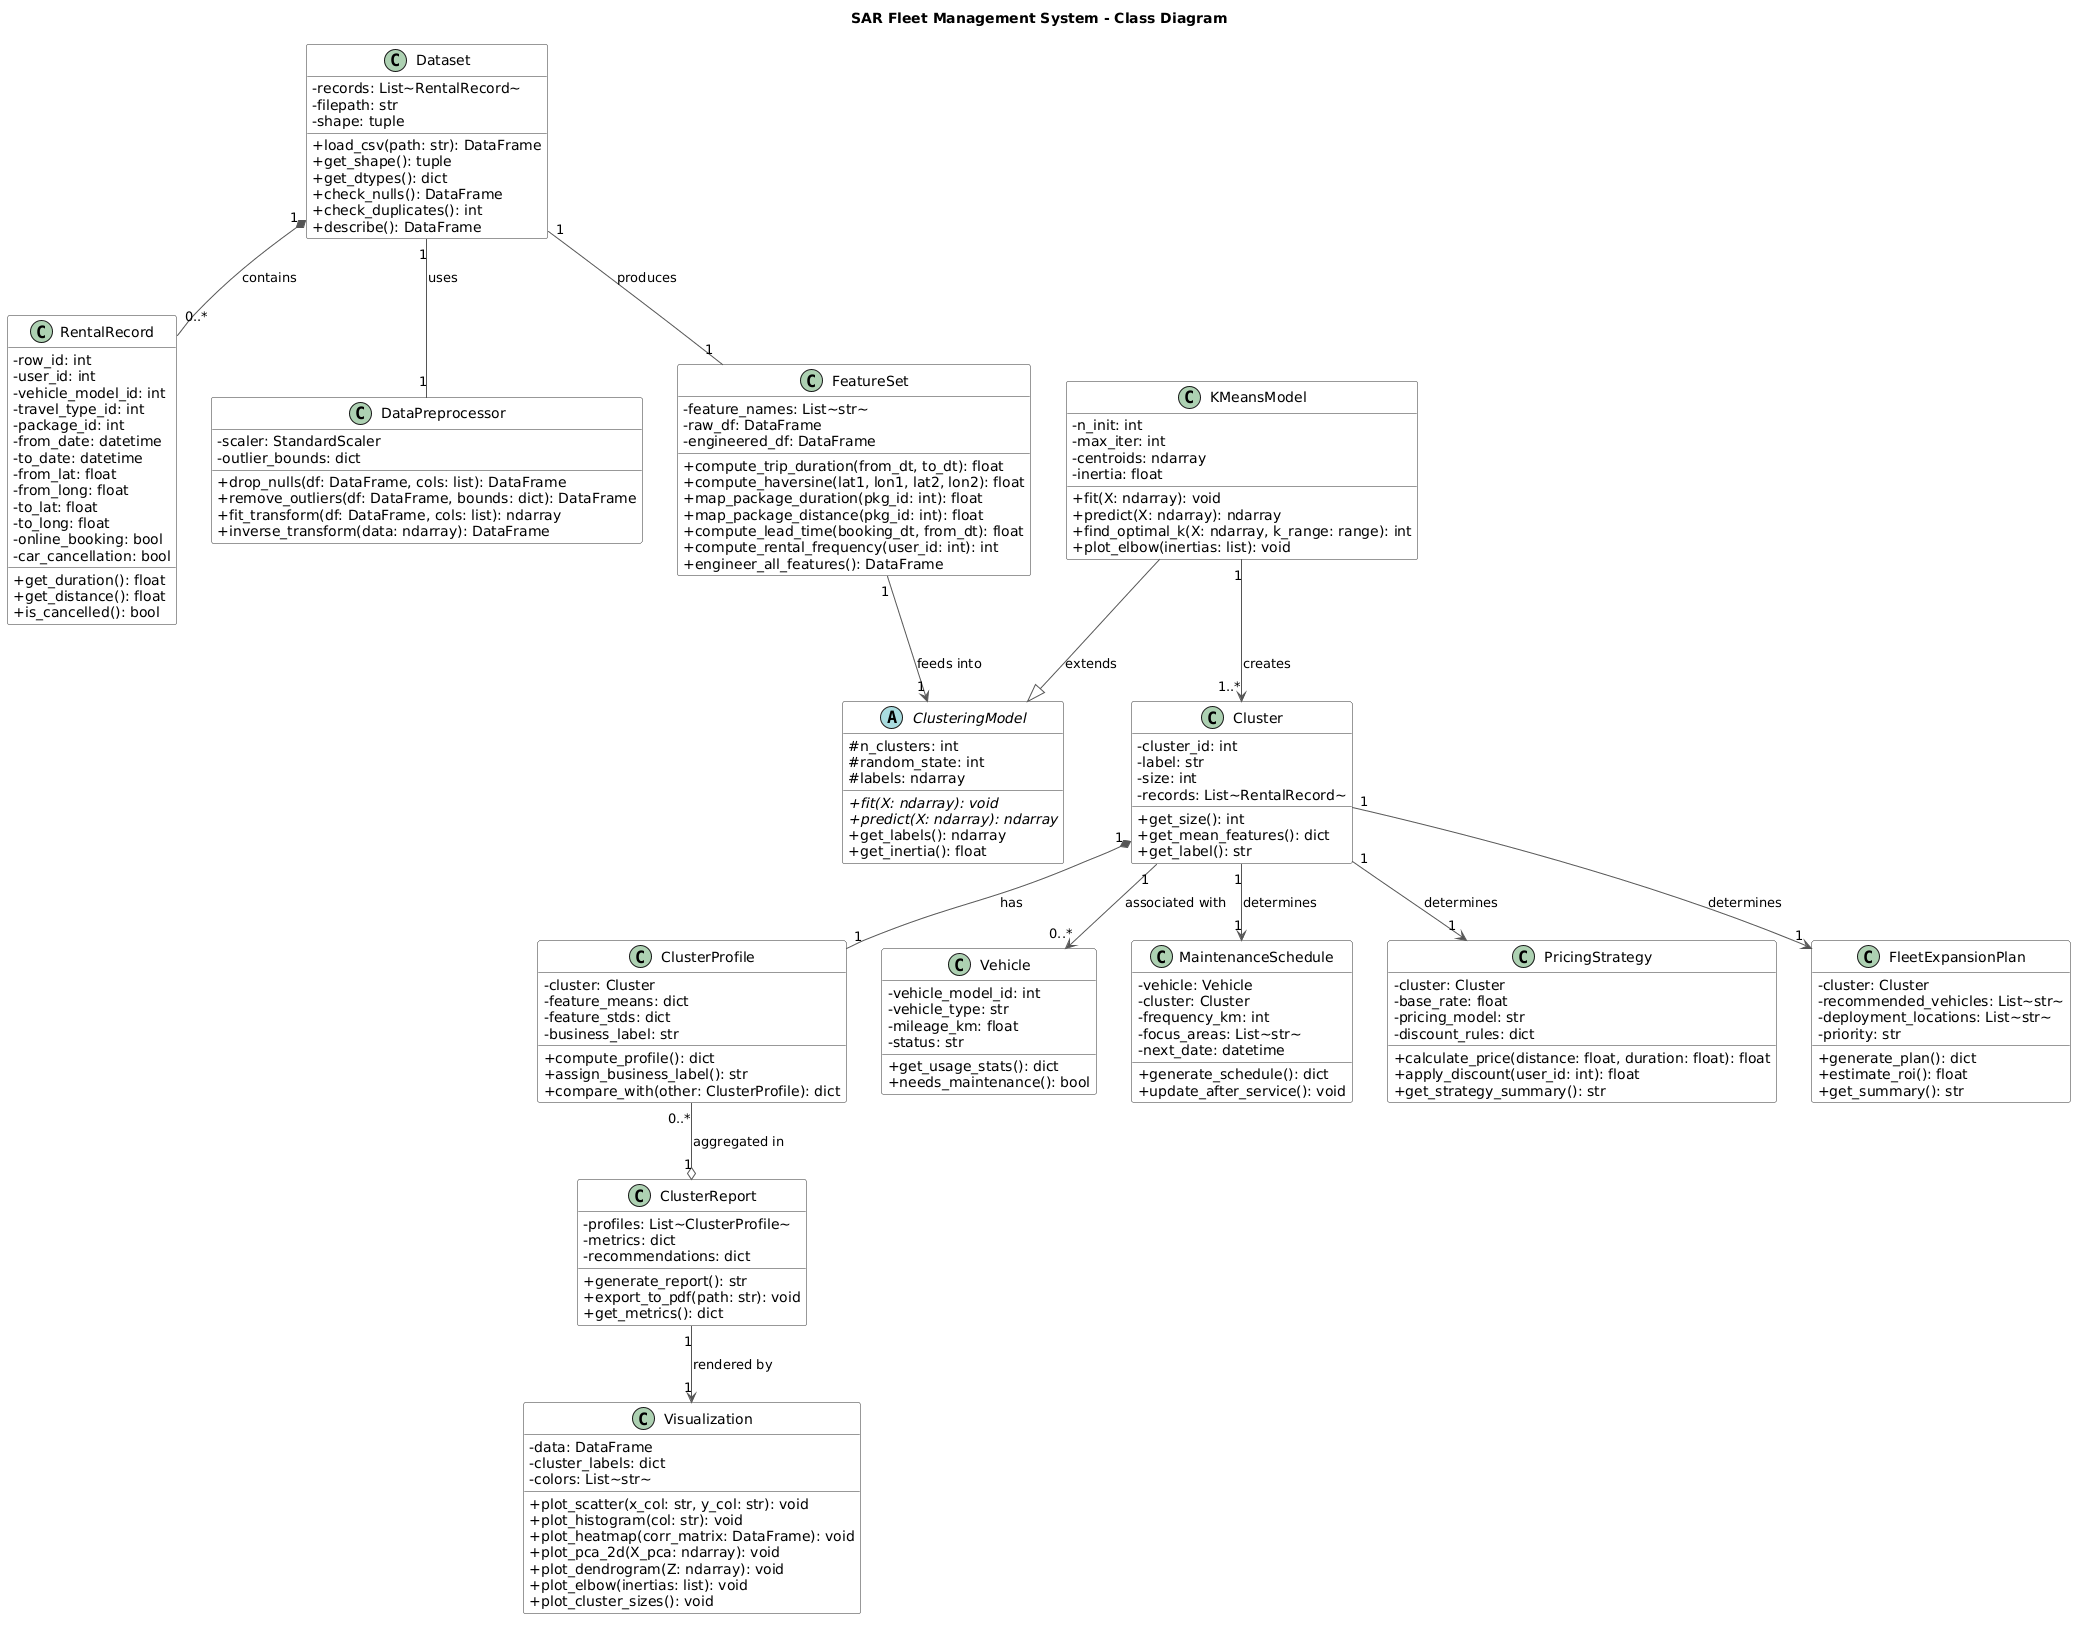

In [37]:
# Display the Class Diagram
print('CLASS DIAGRAM — SAR Fleet Management System')
print('=' * 60)
display(Image(filename='class_diagram.png'))

### 9.3 Written Explanation: Clustering Approach for Fleet Optimization

#### Objective
Our clustering pipeline segments SAR rental trips into distinct behavioral groups using **K-Means**, enabling data-driven decisions for maintenance, pricing, and fleet expansion.

#### Feature Selection Rationale
We engineered 8 features that capture the **who, what, when, and how** of each rental:
- **Trip characteristics**: `trip_duration_hrs` and `trip_distance_km` measure physical usage intensity
- **Package information**: `package_duration_hrs` and `package_distance_km` capture pre-selected service tiers
- **Behavioral signals**: `travel_type`, `booking_lead_time_hrs`, `rental_frequency`, and `online_booking` reveal customer patterns

#### Why K-Means?
- **Scalability**: Handles the 5,000+ record dataset efficiently
- **Interpretability**: Cluster centroids directly map to business-meaningful vehicle usage profiles
- **Well-suited to continuous features**: Our engineered features are all numeric, ideal for K-Means

#### Preprocessing Decisions
- **Complementary null filling**: Package features filled with 0 for non-package trips (and vice versa for GPS distance), preserving the natural distinction between travel types
- **Outlier removal**: Trips under 30 minutes or over 15 hours filtered as anomalies
- **StandardScaler**: Essential for K-Means since it uses Euclidean distance

#### Business Impact

Each cluster receives tailored strategies:
1. **Maintenance**: High-mileage clusters get frequent inspections; urban clusters focus on brake/suspension wear
2. **Pricing**: Long-distance clusters suit per-km models; frequent users benefit from subscription pricing
3. **Fleet Expansion**: Cluster profiles guide vehicle type selection and deployment locations

This clustering framework transforms raw trip data into actionable fleet management intelligence, enabling SAR to optimize operations, reduce costs, and improve customer satisfaction.

---

## Summary

This notebook delivered a complete clustering pipeline for SAR Rental fleet optimization:

| Phase | Description | Status |
|-------|-------------|--------|
| 1 | Data Loading & Exploration | Complete |
| 2 | Feature Engineering (8 features) | Complete |
| 3 | Preprocessing (nulls, outliers, scaling) | Complete |
| 4 | Optimal K Selection (elbow + silhouette) | Complete |
| 5 | K-Means Clustering | Complete |
| 6 | Validation (Silhouette, DB, CH + dendrogram) | Complete |
| 7 | Cluster Profiling & Visualization | Complete |
| 8 | Business Recommendations | Complete |
| 9 | UML Diagrams (Use Case + Class) | Complete |

**Dataset:** SAR Rental Car Service (10,000 trips, San Francisco)  
**Method:** K-Means with StandardScaler, validated by 3 metrics + hierarchical dendrogram  
**Output:** Actionable maintenance, pricing, and fleet expansion strategies per customer segment